In [1]:
%run helperFunctions.ipynb

read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv


In [2]:

def build_autoencoder():
    # ---- Encoder ----
    input_layer = tf.keras.Input(shape=(2,), name="input_v_i")
    
    # A simple 2-layer encoder
    x = layers.Dense(8, activation='relu')(input_layer)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(4, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    # Bottleneck / latent space
    latent = layers.Dense(2, activation='relu', name="latent")(x)
    
    # ---- Decoder ----
    x = layers.Dense(4, activation='relu')(latent)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(8, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    # Final reconstruction to 2 outputs (voltage, current)
    output_layer = layers.Dense(2, activation='linear', name="reconstructed")(x)
    
    # Build and compile
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(
        optimizer='adam',
        loss='mse'  # Typical for autoencoders
    )
    
    return autoencoder

In [3]:
def train(with_validation = False): 
    df = getTrainingDataResistance()
    X = df = getTrainingDataResistance()
    # Extract features
    X = df[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    # Save the scaler for future use
    
    autoencoder = build_autoencoder()

    if with_validation: 
        history = autoencoder.fit(
            X_scaled,  # shape (num_samples, 2)
            X_scaled,  # same as input, because autoencoder targets the input
            epochs=20,
            batch_size=4,
            validation_split=0.1,  # optional: use part of your data for validation
            verbose=1
        )
    else:
        history = autoencoder.fit(
            X_scaled,  # shape (num_samples, 2)
            X_scaled,  # same as input, because autoencoder targets the input
            epochs=20,
            batch_size=4,
            validation_split=0.1,  # optional: use part of your data for validation
            verbose=1
        )
        joblib.dump(scaler, './data/models/autoencoder.save')
        autoencoder.save('./data/models/autoencoder.h5')
        
        
    # Optional: Plot the training loss over epochs
    plt.plot(history.history['loss'], label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.show()
    return autencoder

read: ./data/training/Circuit_ScenarioDataGeneration_Restistance_res.csv
read: ./data/training/Circuit_ScenarioDataGeneration_Restistance_res.csv
Epoch 1/20
1387/1387 [==============================] - 3s 1ms/step - loss: 0.4264 - val_loss: 0.1099
Epoch 2/20
1387/1387 [==============================] - 2s 1ms/step - loss: 0.2132 - val_loss: 0.0829
Epoch 3/20
1387/1387 [==============================] - 2s 1ms/step - loss: 0.1947 - val_loss: 0.0644
Epoch 4/20
1387/1387 [==============================] - 2s 1ms/step - loss: 0.1805 - val_loss: 0.0561
Epoch 5/20
1387/1387 [==============================] - 2s 1ms/step - loss: 0.1632 - val_loss: 0.0476
Epoch 6/20
1387/1387 [==============================] - 2s 1ms/step - loss: 0.1467 - val_loss: 0.0438
Epoch 7/20
1387/1387 [==============================] - 2s 2ms/step - loss: 0.1663 - val_loss: 0.0482
Epoch 8/20
1387/1387 [==============================] - 2s 1ms/step - loss: 0.1575 - val_loss: 0.0452
Epoch 9/20
1387/1387 [================

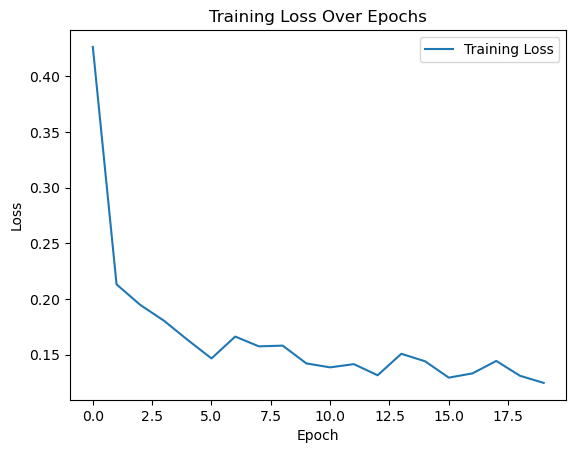

NameError: name 'autencoder' is not defined

In [4]:
autencoder = train()

In [ ]:
# 1) Get reconstruction on training (or validation) data
X_train_pred = autoencoder.predict(X_train_normal)  # shape (num_samples, 2)

# 2) Compute MSE for each sample
reconstruction_errors = np.mean((X_train_pred - X_train_normal) ** 2, axis=1)

# 3) Pick threshold
threshold = np.mean(reconstruction_errors) + 3 * np.std(reconstruction_errors)

print("Computed reconstruction error threshold:", threshold)

In [ ]:
df_d = readDatasInPanda(["./data/Circuit_ScenarioAscend_res.csv"])
X_test_normal = df_d[["circ1.r_load.v", "circ1.r_load.i","circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values

In [ ]:
# 1) Get reconstruction on training (or validation) data
X_test_pred = autoencoder.predict(X_test_normal)  # shape (num_samples, 2)

# 2) Compute MSE for each sample
test_errors = np.mean((X_test_pred - X_test_normal) ** 2, axis=1)

anomaly_mask = test_errors > threshold  # boolean array
#anomalies = X_test[anomaly_mask]
#for test_errors in test_errors: 
   # print(test_errors)

In [ ]:

# 2. Compute reconstruction error on training data
reconstructed_train = autoencoder.predict(X_train_normal)
train_errors = np.mean((reconstructed_train - X_train_normal)**2, axis=1)

mean_error = np.mean(train_errors)
std_error  = np.std(train_errors)
threshold  = 200#mean_error + 3 * std_error

# 3. Test on new data
df_d = readDatasInPanda(["./data/Circuit_ScenarioAscend_res.csv"])
X_test_normal = df_d[["circ1.r_load.v", "circ1.r_load.i", "circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
X_test = df_d[["circ1.r_load.v", "circ1.r_load.i", "circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
reconstructed_test = autoencoder.predict(X_test)
test_errors = np.mean((reconstructed_test - X_test)**2, axis=1)

anomaly_mask = test_errors > threshold

print("Anomaly mask:", anomaly_mask)
print("Number of anomalies:", np.sum(anomaly_mask), "/", len(X_test))

# 4. (Optional) Visualize
plt.hist(train_errors, bins=50, alpha=0.7)
plt.axvline(x=threshold, color='r', linestyle='--')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Histogram of Train Errors with Threshold")
plt.show()

In [ ]:
df_d = readDatasInPanda(["./data/Circuit_ScenarioDataGeneration_res.csv",
                         "./data/Circuit_Scenario1_res.csv", 
                         "./data/Circuit_Scenario2_res.csv", 
                         "./data/Circuit_Scenario3_res.csv", 
                         "./data/Circuit_Scenario4_res.csv",
                         "./data/Circuit_Scenario5_res.csv",
                         "./data/Circuit_Scenario6_res.csv",
                         "./data/Circuit_Scenario7_res.csv",
                         "./data/Circuit_Scenario8_res.csv",
                         "./data/Circuit_Scenario9_res.csv",
                         "./data/Circuit_Scenario10_res.csv",
                         "./data/Circuit_ScenarioVoltageDropsBat_res.csv",
                         "./data/Circuit_ScenarioVoltageSwitch_res.csv"
                        ])
X_test_normal = df_d[["circ1.r_load.v", "circ1.r_load.i", "circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
X_test = df_d[["circ1.r_load.v", "circ1.r_load.i", "circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
reconstructed_test = autoencoder.predict(X_test)
test_errors = np.mean((reconstructed_test - X_test)**2, axis=1)

anomaly_mask = test_errors > threshold
anomolous = getAnomalyMask(df_d)
#print("Anomaly mask:", anomaly_mask)
#print("Anomlys", anomolous)
#for mask, anom, mError in zip(anomaly_mask, anomolous, test_errors):
   # if mask != anom:
      #  print(f"mask : {mask}, anom: {anom}, error {mError}")
      #  print(anom)
      #  print("Error")
        
print("Number of anomalies:", np.sum(anomaly_mask), "/", len(X_test))

# 4. (Optional) Visualize
print("threshhold: ", threshold)
plt.hist(test_errors, bins=50, alpha=0.7)
plt.axvline(x=threshold, color='r', linestyle='--')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Histogram of Train Errors with Threshold")
plt.show()

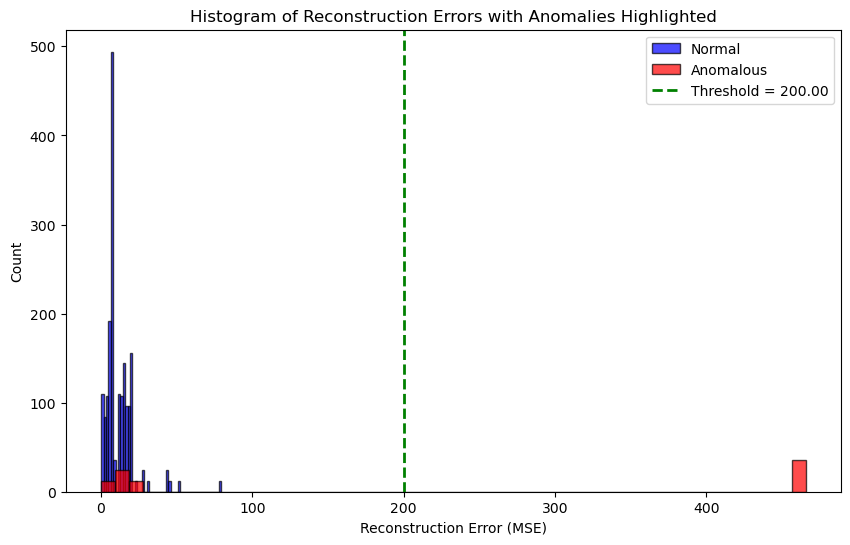

array([1.47646725e-01, 1.47646722e-01, 1.47646722e-01, 1.47646722e-01,
       1.47646722e-01, 1.47646722e-01, 1.47646722e-01, 1.47646722e-01,
       1.47646722e-01, 1.47646722e-01, 1.47646722e-01, 1.47646722e-01,
       4.62631061e+02, 4.62631060e+02, 4.62631060e+02, 4.62631060e+02,
       4.62631060e+02, 4.62631060e+02, 4.62631060e+02, 4.62631060e+02,
       4.62631060e+02, 4.62631060e+02, 4.62631060e+02, 4.62631060e+02,
       4.62631060e+02, 4.62631060e+02, 4.62631060e+02, 4.62631060e+02,
       4.62631060e+02, 4.62631060e+02, 4.62631060e+02, 4.62631060e+02,
       4.62631060e+02, 4.62631060e+02, 4.62631060e+02, 4.62631060e+02,
       4.65607235e+02, 4.65607235e+02, 4.65607235e+02, 4.65607235e+02,
       4.65607235e+02, 4.65607235e+02, 4.65607235e+02, 4.65607235e+02,
       4.65607235e+02, 4.65607235e+02, 4.65607235e+02, 4.65607235e+02,
       1.84950998e+01, 1.84950999e+01, 1.84950999e+01, 1.84950999e+01,
       1.84950999e+01, 1.84950999e+01, 1.84950999e+01, 1.84950999e+01,
      

In [96]:
# Ensure 'anomolous' is a NumPy array
anomolous = np.array(anomolous)

# Define Masks
combined_anomaly_mask = anomaly_mask | anomolous
combined_normal_mask = ~combined_anomaly_mask

# Retrieve Data Points
anomaly_data = test_errors[combined_anomaly_mask]
normal_data  = test_errors[combined_normal_mask]

# Plotting with Matplotlib
plt.figure(figsize=(10, 6))

# Histogram for Normal Errors
plt.hist(
    normal_data, 
    bins=50, 
    alpha=0.7, 
    label='Normal', 
    color='blue', 
    edgecolor='black'
)

# Histogram for Anomalous Errors
plt.hist(
    anomaly_data, 
    bins=50, 
    alpha=0.7, 
    label='Anomalous', 
    color='red', 
    edgecolor='black'
)

# Plot the Threshold Line
plt.axvline(
    x=threshold, 
    color='green', 
    linestyle='--', 
    linewidth=2, 
    label=f'Threshold = {threshold:.2f}'
)

# Add Labels and Title
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Histogram of Reconstruction Errors with Anomalies Highlighted")

# Add Legend
plt.legend()

# Show Plot
plt.show()
anomaly_data

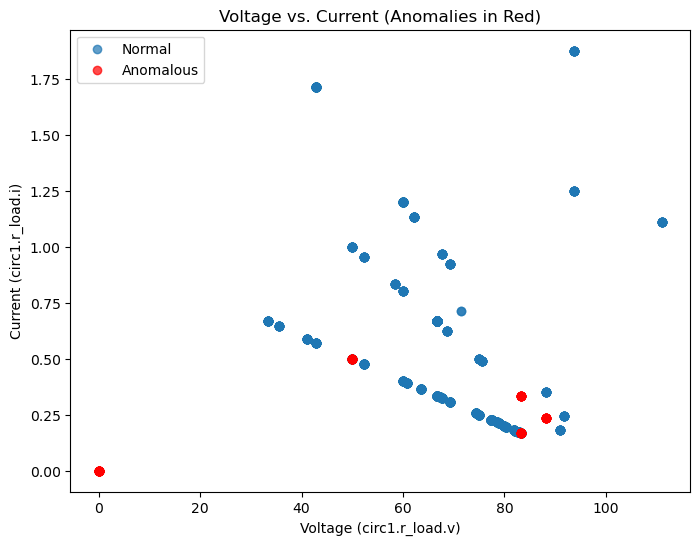

array([[ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [ 5.00000050e+01,  5.00000050e-01],
       [-2.93725861e-08, -1.05945142e-09],
       [ 1.00001785e-09,  1.00002229e-11],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.00001785e-09,  9.99988981e-12],
       [ 1.

In [97]:
X_test = df_d[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values
anomolous = np.array(anomolous)
# Let's define normal vs. anomaly using your mask
normal_mask = ~anomolous        # Invert the boolean mask for normals
anomaly_data = X_test[anomolous]
normal_data  = X_test[normal_mask]

plt.figure(figsize=(8,6))

# Plot normal samples in one color
plt.scatter(
    normal_data[:, 0], 
    normal_data[:, 1], 
    alpha=0.7, 
    label='Normal'
)

# Plot anomalous samples in another color (e.g., red)
plt.scatter(
    anomaly_data[:, 0], 
    anomaly_data[:, 1], 
    alpha=0.7, 
    color='red', 
    label='Anomalous'
)

plt.xlabel("Voltage (circ1.r_load.v)")
plt.ylabel("Current (circ1.r_load.i)")
plt.title("Voltage vs. Current (Anomalies in Red)")
plt.legend()
plt.show()
anomaly_data